In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir("/content/drive/MyDrive/Quantium_Task")

['QVI_purchase_behaviour.csv', 'QVI_transaction_data.xlsx', 'QVI_data.csv']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_columns', None)

In [ ]:
transaction_data = pd.read_excel("/content/drive/MyDrive/Quantium_Task/QVI_transaction_data.xlsx")
customer_data = pd.read_csv("/content/drive/MyDrive/Quantium_Task/QVI_purchase_behaviour.csv")

print("Transaction data shape:", transaction_data.shape)
print("Customer data shape:", customer_data.shape)

transaction_data.head()

Transaction data shape: (264836, 8)
Customer data shape: (72637, 3)


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [ ]:
transaction_data.info()
print("\nMissing values:\n", transaction_data.isnull().sum())
print("\nDuplicate rows:", transaction_data.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB

Missing values:
 DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

Duplicate rows: 1


In [ ]:
transaction_data['DATE'] = pd.to_datetime(transaction_data['DATE'], origin='1899-12-30', unit='D')
transaction_data['DATE'].head()

,DATE
0,2018-10-17
1,2019-05-14
2,2019-05-20
3,2018-08-17
4,2018-08-18


In [ ]:
# See all unique product names
for name in sorted(transaction_data['PROD_NAME'].unique()):
    print(name)

Burger Rings 220g
CCs Nacho Cheese    175g
CCs Original 175g
CCs Tasty Cheese    175g
Cheetos Chs & Bacon Balls 190g
Cheetos Puffs 165g
Cheezels Cheese 330g
Cheezels Cheese Box 125g
Cobs Popd Sea Salt  Chips 110g
Cobs Popd Sour Crm  &Chives Chips 110g
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g
Dorito Corn Chp     Supreme 380g
Doritos Cheese      Supreme 330g
Doritos Corn Chip Mexican Jalapeno 150g
Doritos Corn Chip Southern Chicken 150g
Doritos Corn Chips  Cheese Supreme 170g
Doritos Corn Chips  Nacho Cheese 170g
Doritos Corn Chips  Original 170g
Doritos Mexicana    170g
Doritos Salsa       Medium 300g
Doritos Salsa Mild  300g
French Fries Potato Chips 175g
Grain Waves         Sweet Chilli 210g
Grain Waves Sour    Cream&Chives 210G
GrnWves Plus Btroot & Chilli Jam 180g
Infuzions BBQ Rib   Prawn Crackers 110g
Infuzions Mango     Chutny Papadums 70g
Infuzions SourCream&Herbs Veg Strws 110g
Infuzions Thai SweetChili PotatoMix 110g
Infzns Crn Crnchers Tangy Gcamole 110g
Kettle 135g Swt Pot S

In [ ]:
transaction_data = transaction_data.drop_duplicates()
print("New shape after removing duplicate:", transaction_data.shape)

New shape after removing duplicate: (264835, 8)


In [ ]:
# Remove only those rows where PROD_NAME contains "salsa" (case-insensitive)
transaction_data = transaction_data[~transaction_data['PROD_NAME'].str.contains('salsa', case=False)]

print("New shape after removing salsa products:", transaction_data.shape)

# Verify that no product with the word salsa should remain
print(transaction_data[transaction_data['PROD_NAME'].str.contains('salsa', case=False)]['PROD_NAME'].unique())

New shape after removing salsa products: (246741, 8)
[]


In [ ]:
# Check summary statistics
transaction_data[['PROD_QTY', 'TOT_SALES']].describe()

,PROD_QTY,TOT_SALES
count,246741.000000,246741.000000
mean,1.908061,7.321328
std,0.659832,3.077833
min,1.000000,1.700000
25%,2.000000,5.800000
50%,2.000000,7.400000
75%,2.000000,8.800000
max,200.000000,650.000000


In [ ]:
# Find outlier transactions
outlier = transaction_data[transaction_data['PROD_QTY'] == 200]
print(outlier)

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [ ]:
# View all transactions of this customer
customer_226000 = transaction_data[transaction_data['LYLTY_CARD_NBR'] == 226000]
print(customer_226000)
print("\nTotal transactions by this customer:", len(customer_226000))

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  

Total transactions by this customer: 2


In [ ]:
# Remove this customer from the dataset
transaction_data = transaction_data[transaction_data['LYLTY_CARD_NBR'] != 226000]

print("New shape after removing outlier customer:", transaction_data.shape)

# Verify again to check if any 200 quantity transaction remains
print(transaction_data[transaction_data['PROD_QTY'] == 200])

New shape after removing outlier customer: (246739, 8)
Empty DataFrame
Columns: [DATE, STORE_NBR, LYLTY_CARD_NBR, TXN_ID, PROD_NBR, PROD_NAME, PROD_QTY, TOT_SALES]
Index: []


In [ ]:
# Date-wise transaction count
transactions_by_day = transaction_data.groupby('DATE').size().reset_index(name='N')
print("Total unique dates:", transactions_by_day.shape[0])
transactions_by_day.head()

Total unique dates: 364


,DATE,N
0,2018-07-01,663
1,2018-07-02,650
2,2018-07-03,674
3,2018-07-04,669
4,2018-07-05,660


In [ ]:
# Create full date range (1 July 2018 to 30 June 2019)
all_dates = pd.DataFrame({'DATE': pd.date_range(start='2018-07-01', end='2019-06-30')})

# Merge with actual transaction counts (NaN/0 will appear for missing dates)
transactions_by_day = all_dates.merge(transactions_by_day, on='DATE', how='left')
transactions_by_day['N'] = transactions_by_day['N'].fillna(0)

# Find missing date
missing_date = transactions_by_day[transactions_by_day['N'] == 0]
print("Missing date:", missing_date)

Missing date:           DATE    N
177 2018-12-25  0.0


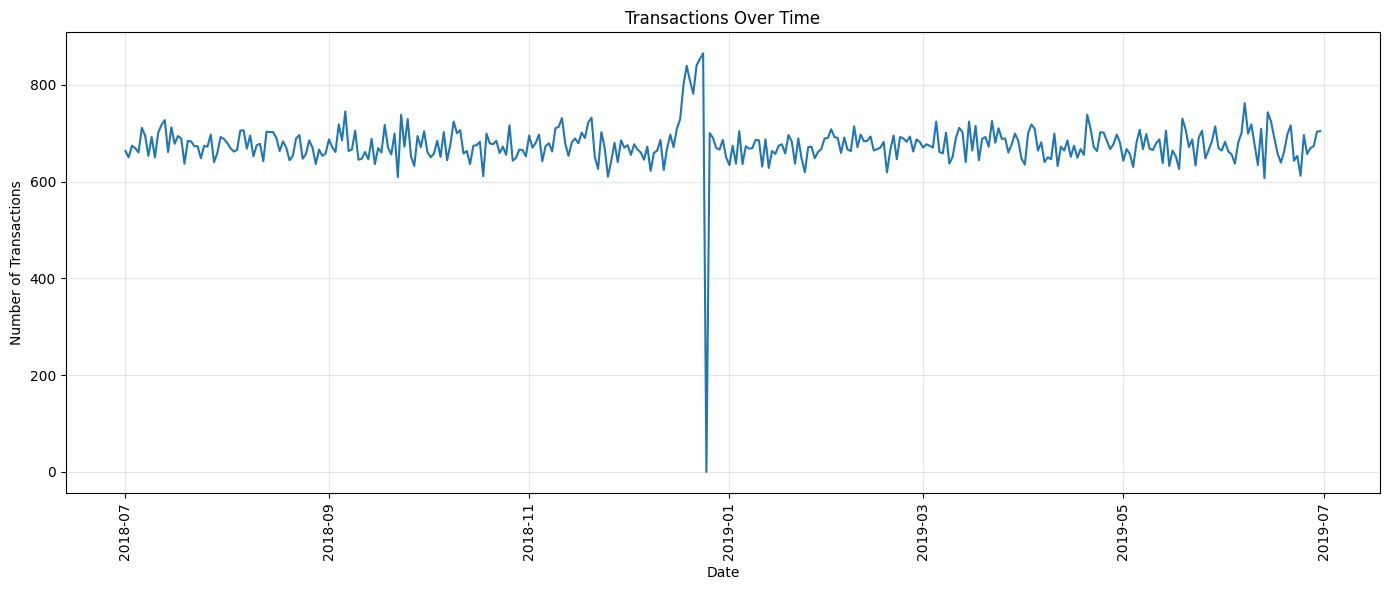

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(transactions_by_day['DATE'], transactions_by_day['N'])
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.title("Transactions Over Time")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

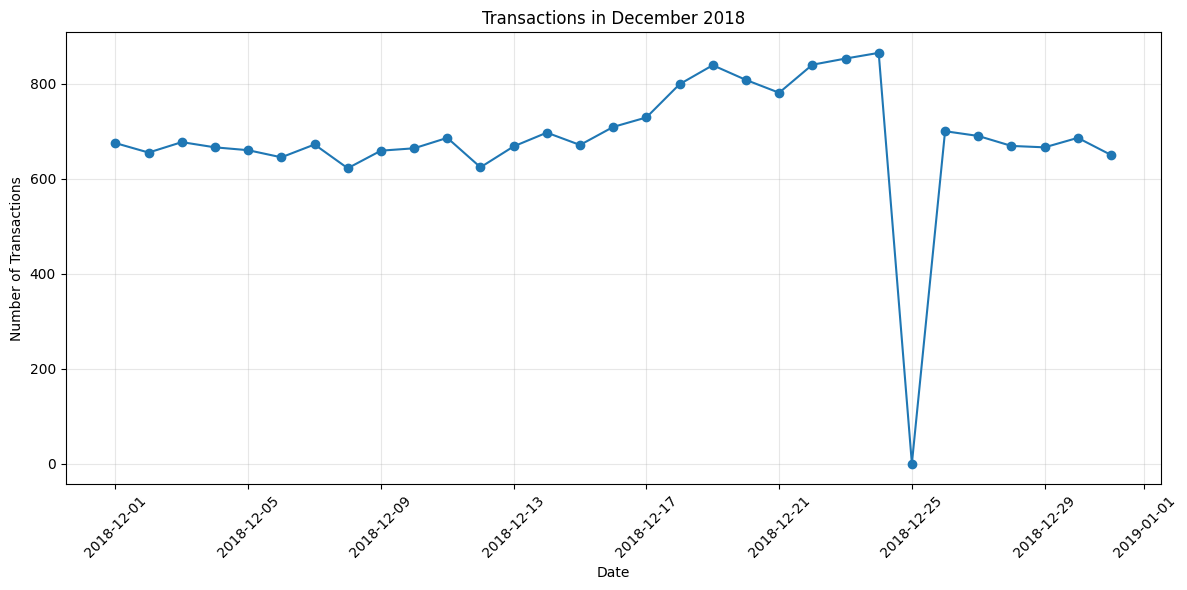

In [ ]:
december_data = transactions_by_day[(transactions_by_day['DATE'] >= '2018-12-01') &
                                      (transactions_by_day['DATE'] <= '2018-12-31')]

plt.figure(figsize=(12,6))
plt.plot(december_data['DATE'], december_data['N'], marker='o')
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.title("Transactions in December 2018")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract numbers (pack size in grams) from PROD_NAME
transaction_data['PACK_SIZE'] = transaction_data['PROD_NAME'].str.extract(r'(\d+)\s?[gG]')[0].astype(int)

# Check if pack sizes are sensible
print(transaction_data['PACK_SIZE'].describe())
print("\nUnique pack sizes:\n", sorted(transaction_data['PACK_SIZE'].unique()))

count    246739.000000
mean        175.583523
std          59.432239
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64

Unique pack sizes:
 [np.int64(70), np.int64(90), np.int64(110), np.int64(125), np.int64(134), np.int64(135), np.int64(150), np.int64(160), np.int64(165), np.int64(170), np.int64(175), np.int64(180), np.int64(190), np.int64(200), np.int64(210), np.int64(220), np.int64(250), np.int64(270), np.int64(330), np.int64(380)]


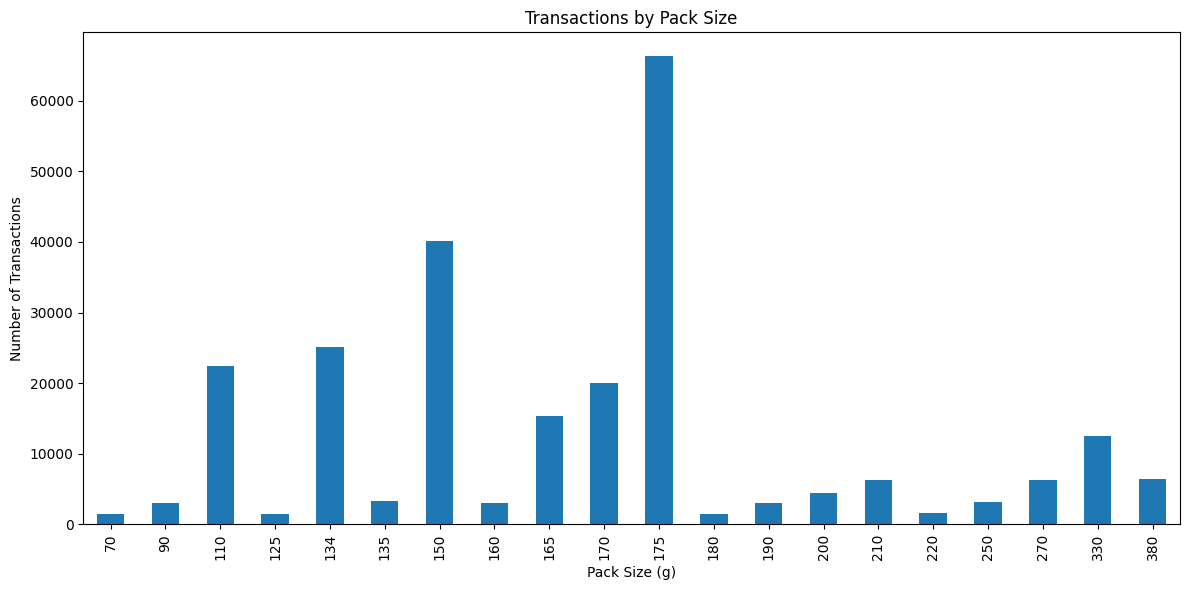

In [ ]:
plt.figure(figsize=(12,6))
transaction_data['PACK_SIZE'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Pack Size (g)")
plt.ylabel("Number of Transactions")
plt.title("Transactions by Pack Size")
plt.tight_layout()
plt.show()

In [ ]:
# PROD_NAME's first word will be the brand name
transaction_data['BRAND'] = transaction_data['PROD_NAME'].str.split().str[0].str.upper()

# Check if brands are sensible
print(sorted(transaction_data['BRAND'].unique()))

['BURGER', 'CCS', 'CHEETOS', 'CHEEZELS', 'COBS', 'DORITO', 'DORITOS', 'FRENCH', 'GRAIN', 'GRNWVES', 'INFUZIONS', 'INFZNS', 'KETTLE', 'NATURAL', 'NCC', 'PRINGLES', 'RED', 'RRD', 'SMITH', 'SMITHS', 'SNBTS', 'SUNBITES', 'THINS', 'TOSTITOS', 'TWISTIES', 'TYRRELLS', 'WOOLWORTHS', 'WW']


In [ ]:
# Merge duplicate/similar brand names
transaction_data['BRAND'] = transaction_data['BRAND'].replace({
    'RED': 'RRD',
    'SNBTS': 'SUNBITES',
    'INFZNS': 'INFUZIONS',
    'WW': 'WOOLWORTHS',
    'SMITH': 'SMITHS',
    'NCC': 'NATURAL',
    'DORITO': 'DORITOS',
    'GRAIN': 'GRNWVES'
})

# Check again - a clean list should be visible now
print(sorted(transaction_data['BRAND'].unique()))
print("\nTotal unique brands:", transaction_data['BRAND'].nunique())

['BURGER', 'CCS', 'CHEETOS', 'CHEEZELS', 'COBS', 'DORITOS', 'FRENCH', 'GRNWVES', 'INFUZIONS', 'KETTLE', 'NATURAL', 'PRINGLES', 'RRD', 'SMITHS', 'SUNBITES', 'THINS', 'TOSTITOS', 'TWISTIES', 'TYRRELLS', 'WOOLWORTHS']

Total unique brands: 20


In [ ]:
# Customer data overview
customer_data.info()
print("\nMissing values:\n", customer_data.isnull().sum())
print("\nLIFESTAGE unique values:\n", customer_data['LIFESTAGE'].unique())
print("\nPREMIUM_CUSTOMER unique values:\n", customer_data['PREMIUM_CUSTOMER'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB

Missing values:
 LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

LIFESTAGE unique values:
 ['YOUNG SINGLES/COUPLES' 'YOUNG FAMILIES' 'OLDER SINGLES/COUPLES'
 'MIDAGE SINGLES/COUPLES' 'NEW FAMILIES' 'OLDER FAMILIES' 'RETIREES']

PREMIUM_CUSTOMER unique values:
 ['Premium' 'Mainstream' 'Budget']


In [ ]:
# How many customers are in each LIFESTAGE and PREMIUM_CUSTOMER category
print(customer_data['LIFESTAGE'].value_counts())
print("\n")
print(customer_data['PREMIUM_CUSTOMER'].value_counts())

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64


PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64


In [ ]:
# Merge both datasets on LYLTY_CARD_NBR (left join)
data = transaction_data.merge(customer_data, on='LYLTY_CARD_NBR', how='left')

print("Transaction data shape:", transaction_data.shape)
print("Merged data shape:", data.shape)

Transaction data shape: (246739, 10)
Merged data shape: (246739, 12)


In [ ]:
# Check if any transaction is left without a matched customer
print("Missing values after merge:\n", data.isnull().sum())

Missing values after merge:
 DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [ ]:
data.to_csv("/content/drive/MyDrive/Quantium_Task/QVI_data.csv", index=False)
print("File saved successfully!")

File saved successfully!


In [ ]:
# Total sales by segment
sales_by_segment = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
sales_by_segment = sales_by_segment.sort_values('TOT_SALES', ascending=False)
print(sales_by_segment)

                 LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES
6           OLDER FAMILIES           Budget  156863.75
19   YOUNG SINGLES/COUPLES       Mainstream  147582.20
13                RETIREES       Mainstream  145168.95
15          YOUNG FAMILIES           Budget  129717.95
9    OLDER SINGLES/COUPLES           Budget  127833.60
10   OLDER SINGLES/COUPLES       Mainstream  124648.50
11   OLDER SINGLES/COUPLES          Premium  123531.55
12                RETIREES           Budget  105916.30
7           OLDER FAMILIES       Mainstream   96413.55
14                RETIREES          Premium   91296.65
16          YOUNG FAMILIES       Mainstream   86338.25
1   MIDAGE SINGLES/COUPLES       Mainstream   84734.25
17          YOUNG FAMILIES          Premium   78571.70
8           OLDER FAMILIES          Premium   75242.60
18   YOUNG SINGLES/COUPLES           Budget   57122.10
2   MIDAGE SINGLES/COUPLES          Premium   54443.85
20   YOUNG SINGLES/COUPLES          Premium   39052.30
0   MIDAGE

<Figure size 1400x700 with 0 Axes>

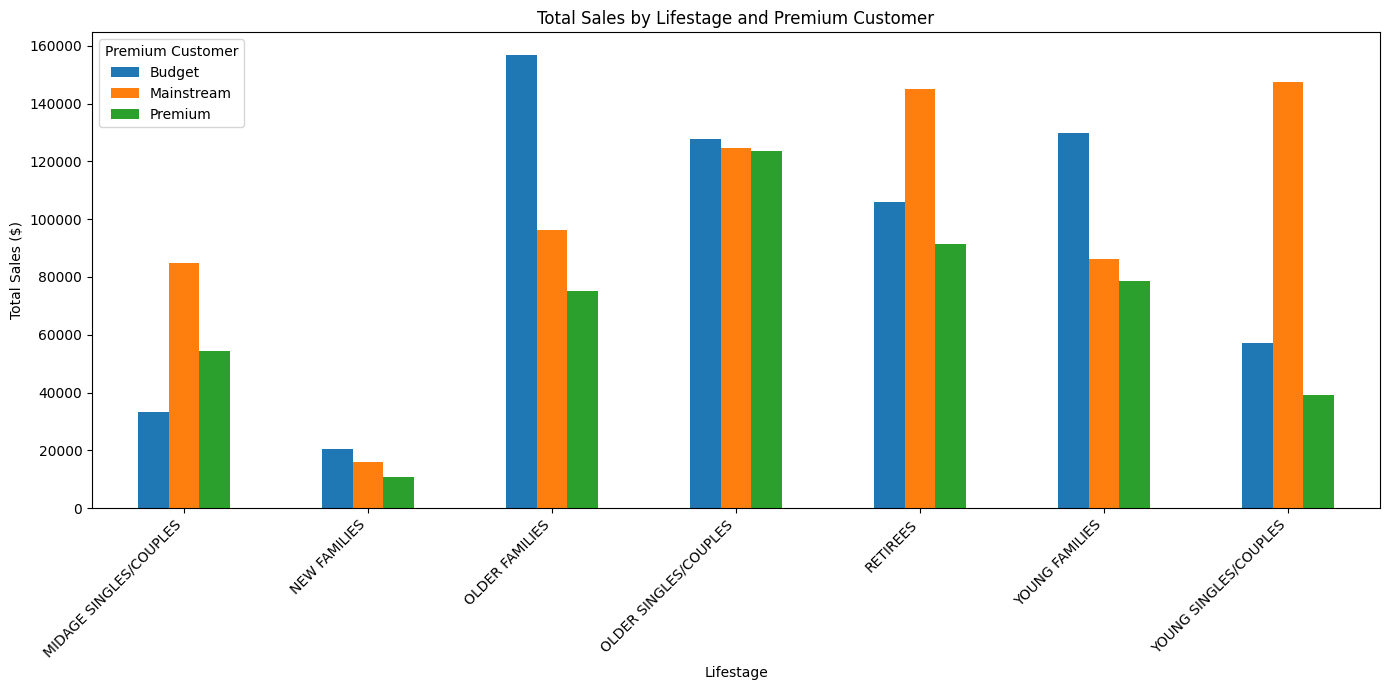

In [ ]:
plt.figure(figsize=(14,7))
pivot_sales = data.pivot_table(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='TOT_SALES', aggfunc='sum')
pivot_sales.plot(kind='bar', figsize=(14,7))
plt.xlabel("Lifestage")
plt.ylabel("Total Sales ($)")
plt.title("Total Sales by Lifestage and Premium Customer")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Premium Customer")
plt.tight_layout()
plt.show()

In [ ]:
# How many unique customers are in each segment
customers_by_segment = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
customers_by_segment.columns = ['LIFESTAGE', 'PREMIUM_CUSTOMER', 'CUSTOMER_COUNT']
customers_by_segment = customers_by_segment.sort_values('CUSTOMER_COUNT', ascending=False)
print(customers_by_segment)

                 LIFESTAGE PREMIUM_CUSTOMER  CUSTOMER_COUNT
19   YOUNG SINGLES/COUPLES       Mainstream            7917
13                RETIREES       Mainstream            6358
10   OLDER SINGLES/COUPLES       Mainstream            4858
9    OLDER SINGLES/COUPLES           Budget            4849
11   OLDER SINGLES/COUPLES          Premium            4682
6           OLDER FAMILIES           Budget            4611
12                RETIREES           Budget            4385
15          YOUNG FAMILIES           Budget            3953
14                RETIREES          Premium            3812
18   YOUNG SINGLES/COUPLES           Budget            3647
1   MIDAGE SINGLES/COUPLES       Mainstream            3298
7           OLDER FAMILIES       Mainstream            2788
16          YOUNG FAMILIES       Mainstream            2685
20   YOUNG SINGLES/COUPLES          Premium            2480
17          YOUNG FAMILIES          Premium            2398
2   MIDAGE SINGLES/COUPLES          Prem

<Figure size 1400x700 with 0 Axes>

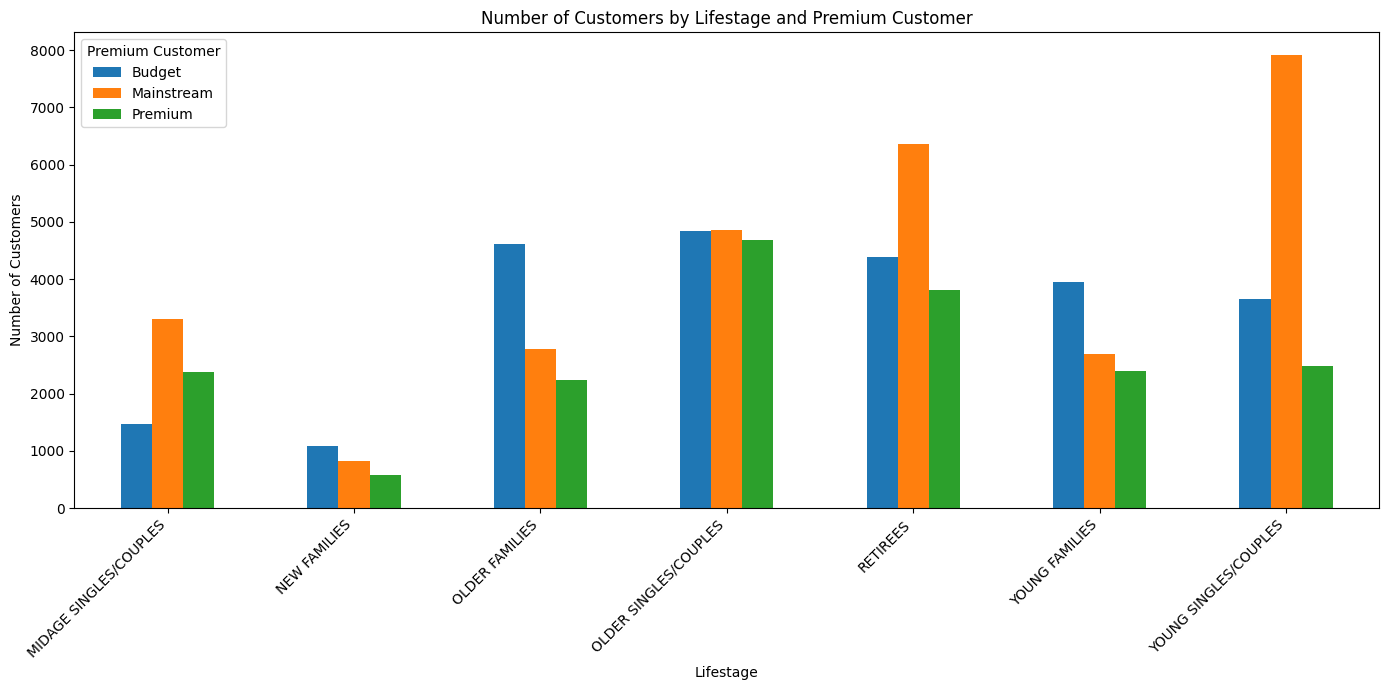

In [ ]:
plt.figure(figsize=(14,7))
pivot_customers = data.pivot_table(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='LYLTY_CARD_NBR', aggfunc='nunique')
pivot_customers.plot(kind='bar', figsize=(14,7))
plt.xlabel("Lifestage")
plt.ylabel("Number of Customers")
plt.title("Number of Customers by Lifestage and Premium Customer")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Premium Customer")
plt.tight_layout()
plt.show()

In [ ]:
# Average units (packets) purchased per customer, by segment
units_per_customer = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    TOTAL_QTY=('PROD_QTY', 'sum'),
    CUSTOMERS=('LYLTY_CARD_NBR', 'nunique')
).reset_index()

units_per_customer['AVG_UNITS_PER_CUSTOMER'] = units_per_customer['TOTAL_QTY'] / units_per_customer['CUSTOMERS']
units_per_customer = units_per_customer.sort_values('AVG_UNITS_PER_CUSTOMER', ascending=False)
print(units_per_customer[['LIFESTAGE', 'PREMIUM_CUSTOMER', 'AVG_UNITS_PER_CUSTOMER']])

                 LIFESTAGE PREMIUM_CUSTOMER  AVG_UNITS_PER_CUSTOMER
7           OLDER FAMILIES       Mainstream                9.255380
6           OLDER FAMILIES           Budget                9.076773
8           OLDER FAMILIES          Premium                9.071717
15          YOUNG FAMILIES           Budget                8.722995
17          YOUNG FAMILIES          Premium                8.716013
16          YOUNG FAMILIES       Mainstream                8.638361
9    OLDER SINGLES/COUPLES           Budget                6.781398
11   OLDER SINGLES/COUPLES          Premium                6.769116
10   OLDER SINGLES/COUPLES       Mainstream                6.712021
1   MIDAGE SINGLES/COUPLES       Mainstream                6.432080
12                RETIREES           Budget                6.141847
14                RETIREES          Premium                6.103358
2   MIDAGE SINGLES/COUPLES          Premium                6.078514
0   MIDAGE SINGLES/COUPLES           Budget     

<Figure size 1400x700 with 0 Axes>

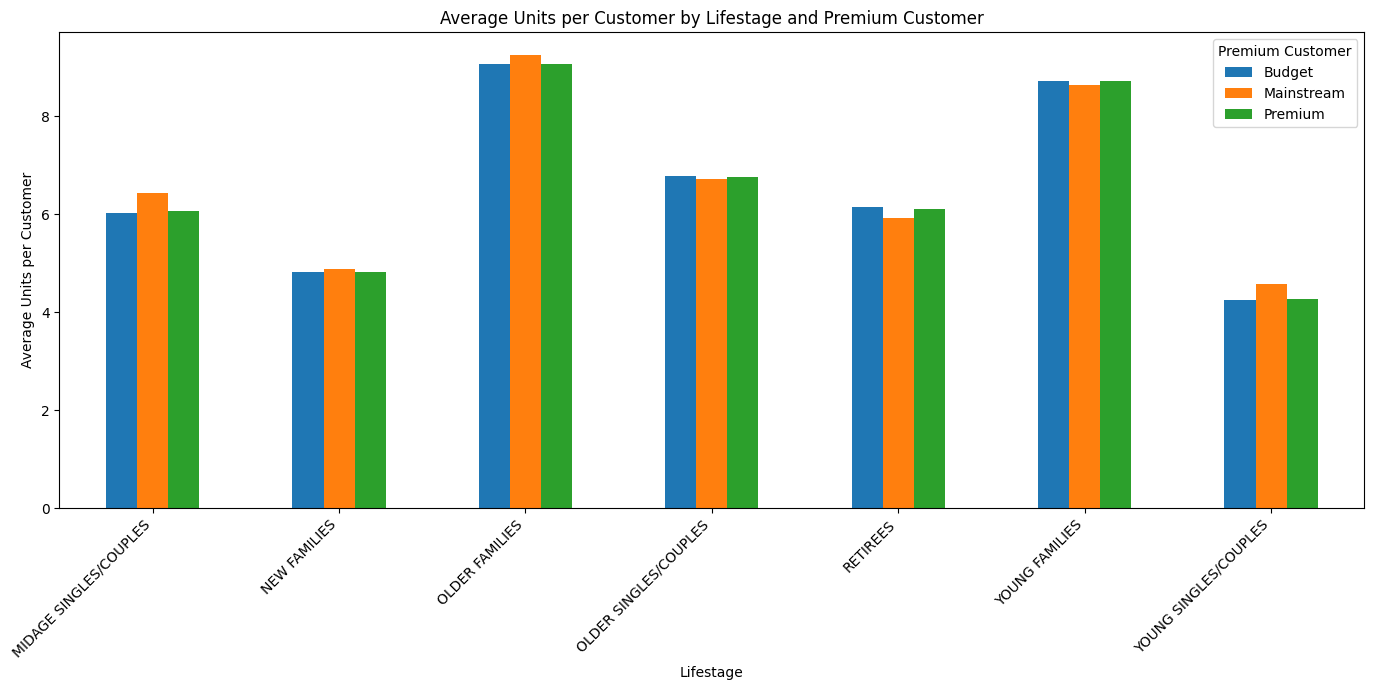

In [ ]:
plt.figure(figsize=(14,7))
pivot_units = units_per_customer.pivot_table(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='AVG_UNITS_PER_CUSTOMER')
pivot_units.plot(kind='bar', figsize=(14,7))
plt.xlabel("Lifestage")
plt.ylabel("Average Units per Customer")
plt.title("Average Units per Customer by Lifestage and Premium Customer")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Premium Customer")
plt.tight_layout()
plt.show()

In [ ]:
#  calculate Price per unit
data['PRICE_PER_UNIT'] = data['TOT_SALES'] / data['PROD_QTY']

# Average price per unit by segment
price_per_unit = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PRICE_PER_UNIT'].mean().reset_index()
price_per_unit = price_per_unit.sort_values('PRICE_PER_UNIT', ascending=False)
print(price_per_unit)

                 LIFESTAGE PREMIUM_CUSTOMER  PRICE_PER_UNIT
19   YOUNG SINGLES/COUPLES       Mainstream        4.065642
1   MIDAGE SINGLES/COUPLES       Mainstream        3.994241
12                RETIREES           Budget        3.924404
14                RETIREES          Premium        3.920942
3             NEW FAMILIES           Budget        3.917688
4             NEW FAMILIES       Mainstream        3.916133
11   OLDER SINGLES/COUPLES          Premium        3.893236
9    OLDER SINGLES/COUPLES           Budget        3.882096
5             NEW FAMILIES          Premium        3.872110
13                RETIREES       Mainstream        3.844294
10   OLDER SINGLES/COUPLES       Mainstream        3.814665
2   MIDAGE SINGLES/COUPLES          Premium        3.770698
17          YOUNG FAMILIES          Premium        3.762150
15          YOUNG FAMILIES           Budget        3.760737
6           OLDER FAMILIES           Budget        3.745340
0   MIDAGE SINGLES/COUPLES           Bud

<Figure size 1400x700 with 0 Axes>

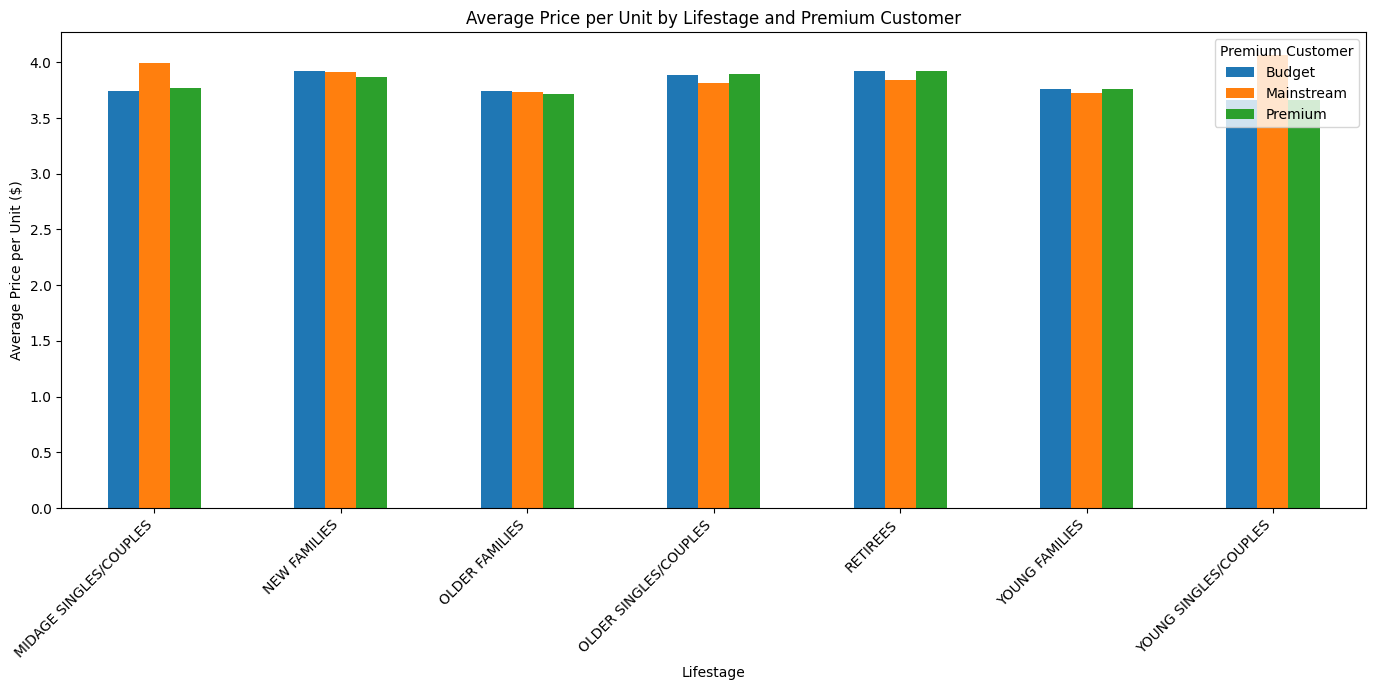

In [ ]:
plt.figure(figsize=(14,7))
pivot_price = data.pivot_table(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='PRICE_PER_UNIT', aggfunc='mean')
pivot_price.plot(kind='bar', figsize=(14,7))
plt.xlabel("Lifestage")
plt.ylabel("Average Price per Unit ($)")
plt.title("Average Price per Unit by Lifestage and Premium Customer")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Premium Customer")
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# Price of Mainstream Young and Midage Singles/Couples
mainstream_ym = data[
    ((data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') | (data['LIFESTAGE'] == 'MIDAGE SINGLES/COUPLES')) &
    (data['PREMIUM_CUSTOMER'] == 'Mainstream')
]['PRICE_PER_UNIT']

# Price of Budget and Premium Young/Midage Singles/Couples
other_ym = data[
    ((data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') | (data['LIFESTAGE'] == 'MIDAGE SINGLES/COUPLES')) &
    (data['PREMIUM_CUSTOMER'] != 'Mainstream')
]['PRICE_PER_UNIT']

# Independent t-test
t_stat, p_value = stats.ttest_ind(mainstream_ym, other_ym, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("\nResult: Difference is statistically significant (p < 0.05)")
else:
    print("\nResult: Difference is NOT statistically significant (p >= 0.05)")

T-statistic: 37.6243885962295
P-value: 6.967354233018139e-306

Result: Difference is statistically significant (p < 0.05)


In [ ]:
# Target segment: Mainstream - Young Singles/Couples
target = data[(data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (data['PREMIUM_CUSTOMER'] == 'Mainstream')]

# Rest of the overall population (excluding target)
rest = data[~((data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (data['PREMIUM_CUSTOMER'] == 'Mainstream'))]

# % share of each brand in the target segment
target_brand = target.groupby('BRAND')['PROD_QTY'].sum() / target['PROD_QTY'].sum() * 100

# % share of each brand in the rest of the population
rest_brand = rest.groupby('BRAND')['PROD_QTY'].sum() / rest['PROD_QTY'].sum() * 100

# Affinity = target % / rest %  (if >1, target segment prefers it more)
brand_affinity = pd.DataFrame({'TARGET_%': target_brand, 'REST_%': rest_brand})
brand_affinity['AFFINITY'] = brand_affinity['TARGET_%'] / brand_affinity['REST_%']
brand_affinity = brand_affinity.sort_values('AFFINITY', ascending=False)

print(brand_affinity)

             TARGET_%     REST_%  AFFINITY
BRAND                                     
TYRRELLS     3.155280   2.569258  1.228090
TWISTIES     4.618357   3.787669  1.219314
DORITOS     12.276052  10.107515  1.214547
KETTLE      19.798482  16.555420  1.195891
TOSTITOS     4.541063   3.797804  1.195708
PRINGLES    11.942029  10.063523  1.186665
COBS         4.463768   3.904904  1.143119
INFUZIONS    6.467909   5.706494  1.133430
THINS        6.037267   5.698663  1.059418
GRNWVES      3.271222   3.118810  1.048868
CHEEZELS     1.797101   1.864699  0.963749
SMITHS       9.636991  12.457966  0.773561
FRENCH       0.394755   0.575809  0.685566
CHEETOS      0.803313   1.206665  0.665730
RRD          4.380952   6.749399  0.649088
NATURAL      1.959972   3.085413  0.635238
CCS          1.118012   1.889574  0.591674
SUNBITES     0.634921   1.258027  0.504696
WOOLWORTHS   2.409938   4.942742  0.487571
BURGER       0.292616   0.659646  0.443595


In [ ]:
# Same affinity analysis for pack size
target_pack = target.groupby('PACK_SIZE')['PROD_QTY'].sum() / target['PROD_QTY'].sum() * 100
rest_pack = rest.groupby('PACK_SIZE')['PROD_QTY'].sum() / rest['PROD_QTY'].sum() * 100

pack_affinity = pd.DataFrame({'TARGET_%': target_pack, 'REST_%': rest_pack})
pack_affinity['AFFINITY'] = pack_affinity['TARGET_%'] / pack_affinity['REST_%']
pack_affinity = pack_affinity.sort_values('AFFINITY', ascending=False)

print(pack_affinity)

            TARGET_%     REST_%  AFFINITY
PACK_SIZE                                
270         3.182885   2.509604  1.268281
380         3.216011   2.558433  1.257024
330         6.128364   5.016215  1.221711
134        11.942029  10.063523  1.186665
110        10.628019   8.979160  1.183632
210         2.912353   2.512138  1.159313
135         1.476881   1.307546  1.129505
250         1.435473   1.278065  1.123161
170         8.077295   8.098634  0.997365
150        15.759834  16.342141  0.964368
175        25.498965  27.000359  0.944394
165         5.565217   6.226795  0.893753
190         0.748102   1.244207  0.601268
180         0.358868   0.606672  0.591536
160         0.640442   1.237298  0.517613
90          0.634921   1.258027  0.504696
125         0.300897   0.603678  0.498440
200         0.897170   1.865620  0.480897
70          0.303658   0.632238  0.480290
220         0.292616   0.659646  0.443595


In [ ]:
## Summary of Findings — Chip Category Analysis

### Data Preparation
The transaction dataset (264,836 rows) was cleaned by removing salsa/dip
products (unrelated to the chips category), fixing the date format, removing
a duplicate row, and excluding an outlier customer (Loyalty Card 226000) who
purchased 200 packets in two separate transactions, indicating commercial
rather than retail purchasing behaviour. Pack size and brand name were
extracted from product names and standardised (e.g., merging "RED" into
"RRD", "WW" into "WOOLWORTHS"). The cleaned transaction data was merged with
customer data (72,637 customers) with no unmatched records, resulting in a
final dataset of 246,739 transactions.

### Key Insights

1. **Top sales-driving segments** are Budget - Older Families ($156,864),
   Mainstream - Young Singles/Couples ($147,582), and Mainstream - Retirees
   ($145,169).

2. **Different segments drive sales differently:**
   - Mainstream - Young Singles/Couples and Mainstream - Retirees generate
     high sales primarily because they represent the largest customer base
     (7,917 and 6,358 customers respectively).
   - Older Families and Young Families generate high sales despite fewer
     customers, because they purchase significantly more units per customer
     (approximately 9 packets on average vs. 4-7 for other segments).

3. **Price sensitivity:** Mainstream Young and Midage Singles/Couples pay
   the highest average price per unit ($4.07 and $3.99 respectively), and
   an independent t-test confirmed this difference is statistically
   significant (p < 0.05). This suggests these customers buy chips more for
   entertainment/social occasions rather than routine consumption, making
   them less price-sensitive.

4. **Brand affinity (target segment: Mainstream Young Singles/Couples):**
   This segment shows a strong preference for Tyrrells, Twisties, Doritos,
   Kettle, and Tostitos — purchasing these brands 20-23% more than the rest
   of the population. They show below-average preference for Woolworths,
   Sunbites, and Natural brands.

5. **Pack size preference:** The same target segment favours larger pack
   sizes (270g, 380g, 330g), purchasing them 22-27% more than the rest of
   the population, while showing lower-than-average preference for the
   most common pack sizes (150g, 175g).

### Commercial Recommendation
To grow chip category sales, we recommend targeting the Mainstream - Young
Singles/Couples segment with increased shelf space, visibility, and
promotions for Tyrrells, Doritos, and Kettle brands in larger pack sizes
(270g and above). This segment combines high customer volume, strong price
tolerance, and clear brand/pack-size preferences, making it the most
commercially attractive segment to target for the upcoming category review.